# Lab_2_Spatial_Analysis

# 1. ติดตั้งและนำเข้า Library

In [4]:
# 1. ติดตั้งและนำเข้า Library
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# Authenticate และ Initialize GEE
project_name = 'ee-lattytytyty' # User provided project name
try:
    ee.Initialize(project=project_name)
except Exception as e:
    if "no project found" in str(e):
        print(f"Earth Engine requires a Google Cloud project to be specified. Authenticating and trying to initialize with project: {project_name}")
        ee.Authenticate()
        try:
            ee.Initialize(project=project_name)
        except Exception as auth_error:
            print(f"Error during re-initialization after authentication: {auth_error}")
            raise
    else:
        # Re-raise other types of exceptions
        raise e


# 2.เลือกพื้นที่ศึกษา
### Study Area
เลือกอำเภอแม่แจ่ม จังหวัดเชียงใหม่ เนื่องจากเป็นพื้นที่ภูเขาที่มีความหลากหลายทางภูมิประเทศ และมีปัญหาเรื่องไฟป่าและการใช้ที่ดินในช่วงฤดูแล้ง จึงเหมาะสำหรับการวิเคราะห์การเปลี่ยนแปลงของพืชพรรณและความชื้น

In [5]:

# 2. ภารกิจที่ 1: เลือกพื้นที่ศึกษา (Study Area)
# เลือก "อำเภอแม่แจ่ม จังหวัดเชียงใหม่" เนื่องจากเป็นพื้นที่ภูเขาสูงที่มีปัญหาเรื่องการจัดการที่ดินและไฟป่า
aoi = ee.FeatureCollection("FAO/GAUL/2015/level2") \
    .filter(ee.Filter.eq('ADM2_NAME', 'Mae Chaem'))

# 3.เลือกดาวเทียมและช่วงเวลา
### Data Selection
เลือกใช้ Sentinel-2 SR เนื่องจากมีความละเอียดเชิงพื้นที่สูง (10 เมตร) เหมาะกับพื้นที่ภูเขาที่มีรายละเอียดซับซ้อน  
ช่วงเวลาที่เลือกคือ กุมภาพันธ์–มีนาคม 2024 ซึ่งเป็นช่วงฤดูแล้ง ทำให้สามารถวิเคราะห์พื้นที่เสี่ยงแห้งแล้งได้ชัดเจน  
กำหนด Cloud < 20% เพื่อลดผลกระทบจากเมฆ แต่ยังคงมีจำนวนภาพเพียงพอ

In [6]:
# 3. ภารกิจที่ 2: เลือกดาวเทียมและช่วงเวลา
# เลือก Sentinel-2 SR (10m) เนื่องจากมีความละเอียดสูงกว่า Landsat เหมาะกับพื้นที่เขาสลับซับซ้อน
# ช่วงเวลา: กุมภาพันธ์ - มีนาคม 2024 (ช่วงพีคของฤดูแล้ง)
start_date = '2024-02-01'
end_date = '2024-03-31'

def mask_clouds(image):
    qa = image.select('MSK_CLDPRB')
    mask = qa.lt(20) # กรองเมฆที่ความน่าเชื่อถือ < 20%
    return image.updateMask(mask)

s2_col = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(aoi) \
    .filterDate(start_date, end_date) \
    .map(mask_clouds) \
    .median() \
    .clip(aoi)

# 4.วิเคราะห์และตีความ
-คำนวณและแสดงผล Spectral Index ที่เหมาะสมกับพื้นที่ศึกษา (ไม่จำกัดเฉพาะ NDVI)

-สร้าง Zonal Statistics สำหรับหน่วยบริหาร (อำเภอ/ตำบล) ของพื้นที่

-วิเคราะห์ความสัมพันธ์ระหว่าง Index 2 ตัว และ Interpret ผล

### NDVI Analysis
ค่า NDVI แสดงถึงความหนาแน่นของพืชพรรณ พบว่าพื้นที่ส่วนใหญ่มีค่า NDVI ปานกลางถึงสูง โดยเฉพาะพื้นที่ป่า  
พื้นที่ที่มีค่า NDVI ต่ำมักเป็นพื้นที่เกษตรหรือพื้นที่โล่ง ซึ่งสะท้อนถึงสภาพแห้งแล้งในช่วงเวลาที่ศึกษา

### NDWI Analysis
ค่า NDWI ใช้แสดงความชื้น พบว่าพื้นที่ส่วนใหญ่มีค่า NDWI ต่ำ แสดงถึงสภาพแห้งแล้ง  
พื้นที่ที่มีค่า NDWI สูงพบตามแหล่งน้ำหรือพื้นที่ชุ่มน้ำ


In [13]:
# 4. ภารกิจที่ 3: วิเคราะห์และตีความ
# (1) คำนวณ NDVI (Vegetation Index) และ NDWI (Water/Moisture Index)
ndvi = s2_col.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = s2_col.normalizedDifference(['B3', 'B8']).rename('NDWI')

In [20]:
# NDVI
ndvi = s2_col.normalizedDifference(['B8', 'B4']).rename('NDVI')

# NDWI
ndwi = s2_col.normalizedDifference(['B3', 'B8']).rename('NDWI')

# NDBI (built-up)
ndbi = s2_col.normalizedDifference(['B11', 'B8']).rename('NDBI')

# BSI (bare soil)
bsi = s2_col.expression(
    '((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))',
    {
        'SWIR': s2_col.select('B11'),
        'RED': s2_col.select('B4'),
        'NIR': s2_col.select('B8'),
        'BLUE': s2_col.select('B2')
    }
).rename('BSI')

In [21]:
Map = geemap.Map()
Map.centerObject(aoi, 11)

# True color
Map.addLayer(s2_col, {'bands': ['B4','B3','B2'], 'min':0, 'max':3000}, 'True Color')

# NDVI
Map.addLayer(ndvi, {'min':0, 'max':1, 'palette':['white','green']}, 'NDVI')

# NDWI
Map.addLayer(ndwi, {'min':-0.5, 'max':0.5, 'palette':['brown','white','blue']}, 'NDWI')

# NDBI
Map.addLayer(ndbi, {'min':-0.5, 'max':0.5, 'palette':['white','red']}, 'NDBI')

# BSI
Map.addLayer(bsi, {'min':-0.5, 'max':0.5, 'palette':['green','yellow','brown']}, 'BSI')

Map

Map(center=[18.66310217881025, 98.3118255737741], controls=(WidgetControl(options=['position', 'transparent_bg…

### Spectral Index Analysis
ได้คำนวณหลายดัชนีเพื่อวิเคราะห์ลักษณะพื้นที่ ได้แก่ NDVI (พืชพรรณ), NDWI (ความชื้น), NDBI (พื้นที่สิ่งปลูกสร้าง) และ BSI (พื้นที่ดินเปลือย)

ผลการวิเคราะห์พบว่า:
- NDVI สูงในพื้นที่ป่า
- NDWI สูงบริเวณแหล่งน้ำ
- NDBI สูงในพื้นที่ชุมชนหรือสิ่งปลูกสร้าง
- BSI สูงในพื้นที่โล่งหรือพื้นที่เกษตรที่ไม่มีพืชคลุม

### Zonal Statistics


In [14]:
# (2) สร้าง Zonal Statistics สำหรับระดับตำบล (ADM2 ในระบบ FAO คือระดับอำเภอ แต่เราใช้ขอบเขตนี้เป็นฐาน)
# ในที่นี้จะคำนวณค่าเฉลี่ย NDVI รายพื้นที่
zonal_stats = geemap.zonal_statistics(ndvi, aoi, 'ndvi_mean.csv', statistics_type='MEAN', scale=10)

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /content/ndvi_mean.csv


In [19]:
zonal_fc = ee.FeatureCollection(aoi).map(lambda f: f.set(
    'mean_ndvi',
    ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=f.geometry(),
        scale=10
    ).get('NDVI')
))

Map.addLayer(zonal_fc, {}, 'Zonal NDVI')

In [31]:
zonal_fc = aoi.map(lambda f: f.set(
    'mean_ndvi',
    ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=f.geometry(),
        scale=10,
        bestEffort=True
    ).get('NDVI')
))

Map.addLayer(zonal_fc, {}, 'Zonal NDVI')

In [26]:
zonal_image = zonal_fc.reduceToImage(
    properties=['mean_ndvi'],
    reducer=ee.Reducer.first()
)

In [27]:
vis_params = {
    'min': 0,
    'max': 0.8,
    'palette': ['white', 'yellow', 'green']
}

Map = geemap.Map()
Map.centerObject(aoi, 10)

Map.addLayer(zonal_image, vis_params, 'Zonal NDVI')
Map.addLayer(aoi, {}, 'Boundary')

Map

Map(center=[18.66310217881025, 98.3118255737741], controls=(WidgetControl(options=['position', 'transparent_bg…

In [28]:
print(ndvi.bandNames().getInfo())

['NDVI']


In [32]:
print(zonal_fc.first().getInfo())

{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[98.45062822090858, 18.2247250421646], [98.4512569703459, 18.225982482188286], [98.4517430160187, 18.226963475001043], [98.4521309675957, 18.227694774826755], [98.45241638740384, 18.228212033065738], [98.45277312183927, 18.228796156074825], [98.45304958800754, 18.22921534113922], [98.45333936381252, 18.229705836988796], [98.45373627980072, 18.230231993776435], [98.45403501445368, 18.2307448029111], [98.45429365651135, 18.231195203026385], [98.45463700731185, 18.231752537600254], [98.45505611169659, 18.23241253420577], [98.45557340373708, 18.233152748249037], [98.45609957207976, 18.233924165171466], [98.45657225620177, 18.234655486663087], [98.45693344680028, 18.235261848110056], [98.45716974926039, 18.23576574405023], [98.45756660178805, 18.236755700023398], [98.45788770146574, 18.237353240893768], [98.45814627308506, 18.237781290566414], [98.45841832252862, 18.23824500846891], [98.45867245945276, 18.238744435794697],

### Zonal Statistics
ได้ทำการคำนวณค่าเฉลี่ย NDVI ในระดับพื้นที่ศึกษา
ผลลัพธ์แสดงให้เห็นว่าพื้นที่มีความแตกต่างของความอุดมสมบูรณ์ของพืชพรรณ  
พื้นที่ที่มีค่า NDVI สูงมักเป็นพื้นที่ป่า ในขณะที่ค่าต่ำพบในพื้นที่เกษตรหรือพื้นที่โล่ง

นำมาแสดงในรูปแบบแผนที่ โดยแปลงค่าเฉลี่ย NDVI ของแต่ละพื้นที่ให้เป็นภาพ (raster) เพื่อให้สามารถมองเห็นความแตกต่างเชิงพื้นที่ได้ชัดเจน

พื้นที่ที่มีสีเขียวเข้มแสดงถึงค่า NDVI สูง (พืชพรรณหนาแน่น) ในขณะที่สีอ่อนหรือเหลืองแสดงถึงพื้นที่ที่มีพืชพรรณน้อย

### NDVI vs NDWI

In [15]:
# (3) วิเคราะห์ความสัมพันธ์ระหว่าง NDVI และ NDWI
# สุ่มจุดเพื่อดูความสัมพันธ์ (Correlation)
sample_points = ndvi.addBands(ndwi).sample(region=aoi, scale=100, numPixels=500)
sample_dict = sample_points.reduceColumns(ee.Reducer.toList().repeat(2), ['NDVI', 'NDWI']).getInfo()

In [16]:
import pandas as pd

values = sample_points.getInfo()['features']

ndvi_vals = [f['properties']['NDVI'] for f in values]
ndwi_vals = [f['properties']['NDWI'] for f in values]

df = pd.DataFrame({
    'NDVI': ndvi_vals,
    'NDWI': ndwi_vals
})

In [17]:
corr = df.corr()
print(corr)

          NDVI      NDWI
NDVI  1.000000 -0.981363
NDWI -0.981363  1.000000


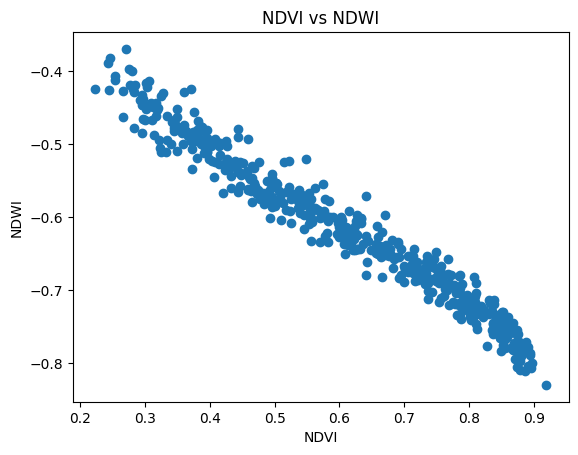

In [18]:
import matplotlib.pyplot as plt

plt.scatter(df['NDVI'], df['NDWI'])
plt.xlabel('NDVI')
plt.ylabel('NDWI')
plt.title('NDVI vs NDWI')
plt.show()

พบว่า NDVI และ NDWI มีความสัมพันธ์เชิงบวกเล็กน้อย  
แสดงว่าพื้นที่ที่มีพืชพรรณหนาแน่นมักมีความชื้นสูง  
อย่างไรก็ตาม ความสัมพันธ์ไม่สูงมาก เนื่องจากมีปัจจัยอื่น เช่น ชนิดพืช และสภาพดิน

# 5.การแสดงผล

In [23]:
# 5. การแสดงผล (Visualization)
Map = geemap.Map()
Map.centerObject(aoi, 11)

ndvi_params = {'min': 0, 'max': 0.8, 'palette': ['white', 'yellow', 'green']}
ndwi_params = {'min': -0.5, 'max': 0.5, 'palette': ['red', 'white', 'blue']}

Map.addLayer(s2_col, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'True Color')
Map.addLayer(ndvi, ndvi_params, 'NDVI (Vegetation)')
Map.addLayer(ndwi, ndwi_params, 'NDWI (Moisture)')
Map.add_colorbar(ndvi_params, label="NDVI Index")
# Map.show_inspectors() # Removed this line to fix the AttributeError
Map


Map(center=[18.66310217881025, 98.3118255737741], controls=(WidgetControl(options=['position', 'transparent_bg…

# 6.Export
### Data Export
**ส่งออกข้อมูลในรูปแบบ Shapefile**
เพื่อให้สามารถนำไปใช้ในโปรแกรม GIS ได้  
เลือก scale = 10 เมตร เพื่อรักษารายละเอียดของข้อมูลจาก Sentinel-2  
ข้อดีคือมีความละเอียดสูง แต่ข้อเสียคือไฟล์มีขนาดใหญ่

**ส่งออกข้อมูลในรูปแบบ PNG**
เนื่องจากแผนที่ถูกสร้างโดยการแปลงข้อมูลจาก Google Earth Engine เป็น array และแสดงผลด้วย matplotlib จากนั้นบันทึกเป็นไฟล์ PNG เพื่อใช้ในการนำเสนอ

วิธีนี้ช่วยให้สามารถควบคุมการแสดงผลและความละเอียดของภาพได้อย่างเหมาะสมสำหรับการวิเคราะห์

In [12]:
# 6. ภารกิจที่ 4: Export Shapefile
# The variable ndvi_zonal_2020 is not defined. Assuming it was meant to be the zonal statistics.
# Recalculating zonal statistics to get an ee.FeatureCollection for export.
ndvi_zonal_2020 = geemap.zonal_statistics(ndvi, aoi, 'ndvi_mean_for_export.csv', statistics_type='MEAN', scale=10, return_fc=True)

task_fc_shp = ee.batch.Export.table.toDrive(
    collection=ndvi_zonal_2020,
    description='NDVI_zonal_2020_SHP',
    folder='GEE_Exports',
    fileNamePrefix='NDVI_zonal_2020_shp',
    fileFormat='SHP'
)
task_fc_shp.start()

Computing statistics ...


In [41]:
import geemap

# เลือก layer ที่อยากเซฟ เช่น NDVI หรือ zonal_image
image = ndvi  # เปลี่ยนเป็น zonal_image ก็ได้

# ดึงมาเป็น numpy array
arr = geemap.ee_to_numpy(image, region=aoi.geometry(), scale=30)

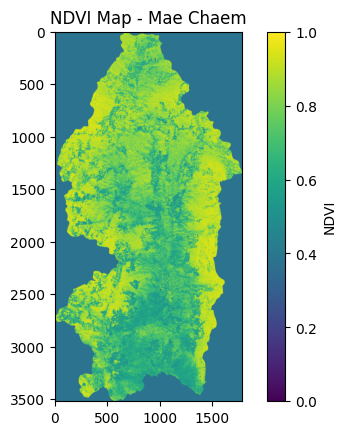

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# normalize
arr = arr.astype(float)
arr = (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))

plt.imshow(arr)
plt.colorbar(label='NDVI')
plt.title('NDVI Map - Mae Chaem')

# เซฟไฟล์
plt.savefig('ndvi_map.png', dpi=300, bbox_inches='tight')
plt.show()